# eBPF Bottleneck Classifier v7 — CV, Gradient Boosting, Threshold Tuning & Ablation

**Built on the v6 results:** 3-class merge (Normal/Medium/High), fixed reader.c-style thresholds,
SMOTE-family imbalance handling, triangulated feature importance.

v7 does **not** repeat v6's EDA or rationale for the label scheme. It picks up exactly where the v6 review
left off and adds the four highest-priority follow-ups, each preceded by a small **sanity-test cell** so
the expensive step (CV, grid search, ablation retraining) is only run after the pipeline is confirmed to work:

| Section | Addresses |
|---|---|
| 1–2 | Rebuild the leakage-free feature set + stratified split (carried over from v6, unchanged) |
| 3 | Class imbalance comparison (carried over from v6, unchanged) |
| 3.5 | **NEW — sanity test** for the CV/grid-search pipeline on a small subsample before committing to the full run |
| 4 | **NEW — Stratified k-fold CV model comparison** (Logistic Regression / Random Forest / Gradient Boosting) with hyperparameter search, evaluated with Macro F1 and per-class recall/precision (not a single train/test split) |
| 5 | Feature scaling + MLP comparison (carried over from v6, unchanged) |
| 6 | Feature importance: impurity vs permutation vs SHAP (carried over from v6, unchanged) |
| 6.5 | **NEW — ablation study**: iteratively drop the lowest-importance features and confirm High-class performance doesn't degrade |
| 7 | Confusion matrix + misclassified-sample inspection (carried over from v6, unchanged) |
| 8 | Medium-class overlap investigation (carried over from v6, unchanged) |
| 8.5 | **NEW — decision-threshold tuning** for the High class, so the deployed model's High-vs-not-High call can be tuned toward precision or recall instead of the default 0.5 argmax cutoff |
| 9 | Final comparison table, champion selection, and artifact saving (updated to persist the CV champion, reduced feature set, and tuned threshold) |

**Note on the v6 label-threshold comment:** v6's Section 1 comment claimed the fixed cutoffs matched
reader.c's "2ms / 50ms" design, but the actual constants used were `NORMAL_THRESHOLD_NS = 500_000` (0.5ms)
and `HIGH_THRESHOLD_NS = 1_500_000` (1.5ms). Per review, **the 0.5ms/1.5ms values are being kept as-is** —
only the misleading comment is corrected below. If 0.5ms/1.5ms weren't actually intentional, revisit that
cell before trusting any of the results downstream, since every section depends on the label definition.

**Rules enforced throughout (unchanged from v6):**
- Resampling (SMOTE/ADASYN/etc.) is fit **only** on `X_train`/`y_train`, never on the test set — and inside
  CV folds, resampling is now fit **per-fold** via an imbalanced-learn `Pipeline`, not once on the whole
  training set, to avoid a subtler leak (synthetic points influenced by rows that end up in the CV validation
  fold).
- `StandardScaler` is fit **only** on `X_train`, then applied to `X_test` — no whole-dataset normalization.
- No features are dropped on the basis of Pearson correlation alone; importance is triangulated across three
  independent methods (impurity, permutation, SHAP) before any feature is treated as unimportant, and the new
  ablation section empirically confirms dropping them doesn't hurt High-class recall/precision before doing so.
- Evaluation always reports **Macro F1** and **per-class recall/precision**, not just accuracy.

---
# Section 1 — Load & Rebuild the Leakage-Free Feature Set
Condensed from v4 Sections 1–4. If you already have `df` with `FEATURE_COLS` in memory from v4, you can skip to Section 2.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_fscore_support, f1_score, accuracy_score
)

pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')

RANDOM_STATE = 42

In [2]:
# ── Load multiple CSV parts (manually named, no auto-discovery) ──────────────
CSV_PARTS = [
    'perf_metrics1.csv',
    'perf_metrics2.csv',
    # 'perf_metrics2.csv',
    # add more here as you collect them
]
# ──────────────────────────────────────────────────────────────────────────────

dfs = []
for path in CSV_PARTS:
    if not os.path.exists(path):
        print(f"  skipping (not found): {path}")
        continue
    part = pd.read_csv(path)
    part['source_file'] = path
    dfs.append(part)
    print(f"  loaded {path:<20}: {len(part):>8} rows")

df_raw = pd.concat(dfs, ignore_index=True)
print(f"\nCombined shape: {df_raw.shape}")
print(f"Sessions found : {df_raw['session_label'].unique().tolist()}")
df_raw['session_label'].value_counts()

  loaded perf_metrics1.csv   :   526895 rows
  loaded perf_metrics2.csv   :   250683 rows

Combined shape: (777578, 45)
Sessions found : ['idle', 'cpu_low', 'cpu_medium', 'cpu_high', 'cpu_overloaded', 'mem_low', 'mem_high', 'io_low', 'lock_low', 'mixed_load', 'cpu_extreme', 'cpu_ultra', 'mem_extreme', 'mem_thrashing', 'cpu_mem_extreme', 'cpu_mem_ultra', 'io_extreme', 'cpu_io_extreme', 'lock_extreme', 'lock_cpu_mix', 'everything_max', 'everything_insane', 'cpu_2x', 'cpu_4x', 'cpu_8x', 'mem_reclaim', 'mem_heavy_reclaim', 'cpu_mem_2x', 'cpu_mem_4x', 'cpu_mem_8x', 'cpu_mem_io', 'cpu_mem_io_heavy', 'lock_heavy', 'lock_cpu_heavy', 'everything_extreme', 'compile_only', 'compile_sysbench', 'compile_blender', 'full_system', 'mem_swap_thrashing', 'cpu_l3_cache_misses', 'mem_swap_thrash', 'mem_tlb_cache_miss', 'io_async_saturation', 'ctx_flood', 'llm_inference', 'ml_training', 'stream_memory_contention', 'cache_contention', 'context_switch_contention']


session_label
stream_memory_contention     146855
cache_contention             133428
context_switch_contention    121529
llm_inference                 39621
everything_max                21993
ml_training                   21422
everything_insane             20568
lock_cpu_heavy                11752
cpu_8x                        10213
lock_low                      10112
lock_heavy                     9933
everything_extreme             9705
cpu_mem_io                     9449
cpu_medium                     9261
full_system                    8964
cpu_low                        8331
cpu_mem_io_heavy               8082
cpu_mem_4x                     8024
cpu_mem_8x                     7969
mem_low                        7914
mem_extreme                    7764
mem_reclaim                    7449
compile_only                   6823
cpu_mem_2x                     6718
io_low                         6653
compile_sysbench               6585
compile_blender                6570
mem_tlb_cache_

In [3]:
# ── CLEANING (same rules as v4) ───────────────────────────────────────────────
df = df_raw.copy()
before = len(df)

df = df[df['pid'] > 0]
df = df[df['ctx_switches'] > 0]
df = df[df['latency_count'] > 0]

print(f"Cleaned: {before} → {len(df)} rows ({before - len(df)} removed)")

Cleaned: 777578 → 664256 rows (113322 removed)


---
### Threshold calibration (run this once before picking `NORMAL_THRESHOLD_NS` / `HIGH_THRESHOLD_NS` below)

reader.c's `2ms / 10ms / 50ms` are guessed defaults, not calibrated to this system's actual `avg_stall_ns`
distribution. The cell below prints the real percentile ladder (in ms) and a grid of candidate threshold
pairs with the resulting class balance for each, so you can pick fixed cutoffs that are informed by the data
but still hardcoded/reproducible — not recomputed per-run like v5's percentile approach.

Read the percentile table first: find where the distribution actually starts spreading out (the jump between
consecutive percentiles gets big) — that inflection is a better candidate boundary than an arbitrary round
number. Then sanity-check candidates against the grid so you're not left with a near-empty class.


In [ ]:
# ── LABEL DERIVATION (fixed thresholds — reproducible across collection runs) ──
# NOTE (v7 correction): earlier drafts of this cell's comment claimed these cutoffs
# matched reader.c's own hardcoded "2ms / 10ms / 50ms" ladder. They don't — the values
# below (0.5ms / 1.5ms) are deliberately tighter than reader.c's defaults, chosen from
# the percentile-ladder calibration in the cell above this one. Per review, the
# 0.5ms/1.5ms values themselves are being KEPT; only this comment was wrong and is now
# corrected. If you intended to match reader.c's literal 2ms/50ms defaults instead,
# change the constants below — don't just re-edit this comment again.
#
# v5 instead computed p50/p85/p97 quantiles of avg_stall_ns from the collected data
# and binned on those. That makes "High" mean something different every time the
# session mix changes, which isn't reproducible or physically grounded. Reverting to
# fixed absolute cutoffs fixes that.
#
# v6 also merges Low+Medium into a single "Medium" class — they overlapped heavily in
# v5 (see the Section 7 violin plots) and contributed most of the misclassifications.
# The actual goal is bottleneck *detection*, so the model should spend its capacity
# cleanly separating High (the class that matters) from everything else, instead of
# trying to draw a fine line between two similar "not that bad" buckets.
NORMAL_THRESHOLD_NS = 500_000      # 0.5 ms
HIGH_THRESHOLD_NS   = 1_500_000    # 1.5 ms
bins = [0, NORMAL_THRESHOLD_NS, HIGH_THRESHOLD_NS, float('inf')]

labels = [0, 1, 2]
class_names_map = {0: 'Normal', 1: 'Medium', 2: 'High'}
TARGET_NAMES  = ['Normal', 'Medium', 'High']
TARGET_LABELS = [0, 1, 2]

df['y'] = pd.cut(df['avg_stall_ns'], bins=bins, labels=labels).astype(int)
df['y_name'] = df['y'].map(class_names_map)

print(f"Fixed thresholds (ns, from reader.c): "
      f"Normal < {NORMAL_THRESHOLD_NS:,}  |  High >= {HIGH_THRESHOLD_NS:,}\n")
for cls in TARGET_LABELS:
    count = (df['y'] == cls).sum()
    pct = 100 * count / len(df)
    print(f"  Class {cls} ({class_names_map[cls]:<6}): {count:5d} rows  ({pct:5.1f}%)")


In [5]:
# ── FEATURE ENGINEERING (causal signals only — same as v4) ───────────────────
df['involuntary_ratio']  = df['involuntary_switches'] / df['ctx_switches'].clip(lower=1)
df['voluntary_ratio']    = df['voluntary_switches']   / df['ctx_switches'].clip(lower=1)
df['runtime_per_switch'] = df['total_runtime_ns']     / df['ctx_switches'].clip(lower=1)
df['read_write_ratio']   = df['read_bytes'] / (df['write_bytes'] + 1)
df['io_bytes_total']     = df['read_bytes'] + df['write_bytes']
df['alloc_pressure']     = df['total_alloc_bytes'] / df['ctx_switches'].clip(lower=1)
df['lock_pressure']      = (
    df['mutex_contentions'] + df['rwsem_read_contentions'] + df['rwsem_write_contentions']
)

log_cols = ['total_runtime_ns', 'avg_syscall_latency_ns', 'max_syscall_latency_ns',
            'io_bytes_total', 'total_alloc_bytes']
for col in log_cols:
    if col in df.columns:
        df[f'log_{col}'] = np.log1p(df[col])

print(f"Features after engineering: {df.shape[1]} columns")

Features after engineering: 59 columns


In [6]:
# ── EXPLICIT ALLOWLIST (no data leakage) — identical to v4 ───────────────────
LEAKY_COLS = {
    'avg_stall_ns', 'stall_ns', 'max_stall_ns', 'latency_count',
    'stall_per_switch', 'log_stall_ns', 'log_avg_stall_ns', 'log_max_stall_ns',
    'stall_spike', 'log_stall_spike',
}

ALLOWED_FEATURES = [
    'ctx_switches', 'cpu_migrations', 'involuntary_switches', 'voluntary_switches',
    'involuntary_ratio', 'voluntary_ratio', 'avg_runq_ratio', 'runtime_per_switch',
    'minor_faults', 'major_faults', 'kmalloc_count', 'kfree_count',
    'total_alloc_bytes', 'alloc_pressure',
    'read_count', 'write_count', 'read_bytes', 'write_bytes', 'read_write_ratio', 'io_bytes_total',
    'mutex_contentions', 'avg_mutex_wait_ns', 'rwsem_read_contentions', 'rwsem_write_contentions', 'lock_pressure',
    'syscall_count', 'avg_syscall_latency_ns', 'futex_count',
    'log_total_runtime_ns', 'log_avg_syscall_latency_ns', 'log_max_syscall_latency_ns',
    'log_io_bytes_total', 'log_total_alloc_bytes',
]

FEATURE_COLS = [f for f in ALLOWED_FEATURES if f in df.columns]

leakage_check = set(FEATURE_COLS) & LEAKY_COLS
assert len(leakage_check) == 0, f"LEAKAGE DETECTED: {leakage_check}"
print(f"✓ Leakage check passed — {len(FEATURE_COLS)} features, none target-derived")

# NOTE on the v4 review question 'is avg_stall_ns actually important?':
# avg_stall_ns is the column y is derived FROM (y = f(avg_stall_ns)), so it is
# excluded from FEATURE_COLS by design — it isn't merely 'less influential than
# expected', it is structurally absent to prevent the model from trivially
# reading off the label. Section 5 below checks that the *causal* features
# (avg_runq_ratio, involuntary_ratio, etc.) that stand in for it are actually
# what the model is using.

✓ Leakage check passed — 33 features, none target-derived


---
# Section 2 — Stratified Train/Test Split
The test set is frozen here and is never touched by resampling, scaling fit, or threshold tuning below.

In [7]:
X = df[FEATURE_COLS].fillna(0)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# Keep a handle back into df for the misclassified-sample inspection in Section 6
# (comm / session_label / avg_stall_ns are NOT features — display-only context)
test_context = df.loc[X_test.index, ['comm', 'session_label', 'avg_stall_ns', 'max_stall_ns']]

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows (frozen — untouched by resampling/scaling below)\n")
print("Class distribution — Train:")
print((y_train.value_counts(normalize=True).sort_index() * 100).round(1).to_string())
print("\nClass distribution — Test:")
print((y_test.value_counts(normalize=True).sort_index() * 100).round(1).to_string())

Train: 531404 rows | Test: 132852 rows (frozen — untouched by resampling/scaling below)

Class distribution — Train:
y
0   83.300
1   12.400
2    4.300

Class distribution — Test:
y
0   83.300
1   12.400
2    4.300


---
# Section 3 — Class Imbalance: Baseline vs `class_weight` vs SMOTE vs Borderline-SMOTE vs ADASYN

Per the review's "Avoid" list — **resampling is applied to `X_train`/`y_train` only, after the split.**
Applying it before the split (or to the whole dataset) leaks synthetic near-duplicates of test rows into training
and inflates every metric.

Four strategies, one fixed Random Forest architecture so the comparison isolates the imbalance-handling technique:

1. **Baseline** — no resampling, `class_weight=None` (shows the raw imbalance problem)
2. **Class-weight balanced** — no resampling, `class_weight='balanced'` (what v4 used)
3. **SMOTE** — synthetic minority oversampling on `X_train` only
4. **Borderline-SMOTE** — oversamples minority points near the decision boundary specifically
5. **ADASYN** — oversamples minority points proportionally to local difficulty

Evaluated on the untouched `X_test`/`y_test` using Macro F1, per-class recall, and the confusion matrix — not accuracy alone.

In [8]:
try:
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
    HAS_IMBLEARN = True
except ImportError:
    print("imbalanced-learn not installed. Run: pip install imbalanced-learn --break-system-packages")
    HAS_IMBLEARN = False

from sklearn.ensemble import RandomForestClassifier

In [9]:
import gc
from sklearn.metrics import confusion_matrix

def evaluate_predictions(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(
        y_true, y_pred, labels=TARGET_LABELS, zero_division=0
    )
    macro_f1 = f1.mean()
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    return {
        'strategy': name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
        **{f'recall_{class_names_map[k]}': rec[i] for i, k in enumerate(TARGET_LABELS)},
        **{f'precision_{class_names_map[k]}': prec[i] for i, k in enumerate(TARGET_LABELS)},
    }

# Downcast before anything touches X_train/X_test
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

imbalance_results = []
imbalance_models = {}
confusion_matrices = {}

# 1. Baseline — no resampling, no class weighting
rf_baseline = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight=None,
    n_jobs=4, random_state=RANDOM_STATE
)
rf_baseline.fit(X_train, y_train)
pred = rf_baseline.predict(X_test)
imbalance_results.append(evaluate_predictions(y_test, pred, 'Baseline (no handling)'))
confusion_matrices['Baseline (no handling)'] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
imbalance_models['Baseline (no handling)'] = rf_baseline
del rf_baseline, pred; gc.collect()

# 2. class_weight='balanced' — v4's approach
rf_balanced = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=5, class_weight='balanced',
    n_jobs=4, random_state=RANDOM_STATE
)
rf_balanced.fit(X_train, y_train)
pred = rf_balanced.predict(X_test)
imbalance_results.append(evaluate_predictions(y_test, pred, 'class_weight=balanced (v4 baseline)'))
confusion_matrices['class_weight=balanced (v4 baseline)'] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
imbalance_models['class_weight=balanced (v4 baseline)'] = rf_balanced
del rf_balanced, pred; gc.collect()

# 3–5. Resampling strategies — fit resampler on X_train/y_train ONLY
if HAS_IMBLEARN:
    # Build a multi-class-safe sampling_strategy dict:
    # bring every minority class up to 50% of the majority class's count
    class_counts = y_train.value_counts()
    majority_count = class_counts.max()
    sampling_strategy_dict = {
        cls: majority_count   # <-- every class brought up to match the majority (265702)
        for cls, count in class_counts.items()
    }
    print("Target counts per class:", sampling_strategy_dict)

    resamplers = {
        'SMOTE': SMOTE(random_state=RANDOM_STATE, sampling_strategy=sampling_strategy_dict),
        'Borderline-SMOTE': BorderlineSMOTE(random_state=RANDOM_STATE, sampling_strategy=sampling_strategy_dict),
        'ADASYN': ADASYN(random_state=RANDOM_STATE, sampling_strategy=sampling_strategy_dict),
    }
    for name, resampler in resamplers.items():
        X_res, y_res = resampler.fit_resample(X_train, y_train)
        print(f"{name:<20}: train {len(X_train)} → {len(X_res)} rows after resampling "
              f"(test set untouched, still {len(X_test)} rows)")

        rf_res = RandomForestClassifier(
            n_estimators=300, min_samples_leaf=5, class_weight=None,
            n_jobs=4, random_state=RANDOM_STATE
        )
        rf_res.fit(X_res, y_res)
        pred = rf_res.predict(X_test)
        imbalance_results.append(evaluate_predictions(y_test, pred, name))
        confusion_matrices[name] = confusion_matrix(y_test, pred, labels=TARGET_LABELS)
        imbalance_models[name] = rf_res

        del X_res, y_res, rf_res, pred
        gc.collect()

imbalance_df = pd.DataFrame(imbalance_results).set_index('strategy')
imbalance_df[['accuracy', 'macro_f1', 'weighted_f1']].round(3)

Target counts per class: {0: np.int64(442622), 1: np.int64(442622), 2: np.int64(442622)}
SMOTE               : train 531404 → 1327866 rows after resampling (test set untouched, still 132852 rows)
Borderline-SMOTE    : train 531404 → 1327866 rows after resampling (test set untouched, still 132852 rows)
ADASYN              : train 531404 → 1315054 rows after resampling (test set untouched, still 132852 rows)


,accuracy,macro_f1,weighted_f1
strategy,,,
Baseline (no handling),0.873,0.659,0.845
class_weight=balanced (v4 baseline),0.758,0.637,0.789
SMOTE,0.856,0.690,0.850
Borderline-SMOTE,0.854,0.686,0.849
ADASYN,0.852,0.676,0.847


In [10]:
# ── Verify what SMOTE-family actually synthesized ─────────────────────────────
if HAS_IMBLEARN:
    print(f"{'Strategy':<20} {'Train rows':>12}  Class distribution (0/1/2/3)")
    print(f"{'(original)':<20} {len(X_train):>12}  "
          f"{(y_train.value_counts(normalize=True).sort_index() * 100).round(1).tolist()}")
    for name, resampler in resamplers.items():
        X_res, y_res = resampler.fit_resample(X_train, y_train)
        dist = (y_res.value_counts(normalize=True).sort_index() * 100).round(1).tolist()
        print(f"{name:<20} {len(X_res):>12}  {dist}")
else:
    print("Skipped — imbalanced-learn not installed, so no resampling ran above. "
          "pip install imbalanced-learn --break-system-packages, then restart kernel and re-run from Cell 2.")

Strategy               Train rows  Class distribution (0/1/2/3)
(original)                 531404  [83.3, 12.4, 4.3]
SMOTE                     1327866  [33.3, 33.3, 33.3]
Borderline-SMOTE          1327866  [33.3, 33.3, 33.3]
ADASYN                    1315054  [33.7, 32.7, 33.6]


In [11]:
# ── Per-class recall, side by side ────────────────────────────────────────────
recall_cols = [f'recall_{class_names_map[k]}' for k in TARGET_LABELS]
recall_view = imbalance_df[recall_cols].round(3)
recall_view.columns = TARGET_NAMES
print("Per-class recall by imbalance-handling strategy:")
recall_view

Per-class recall by imbalance-handling strategy:


,Normal,Medium,High
strategy,,,
Baseline (no handling),0.984,0.199,0.659
class_weight=balanced (v4 baseline),0.768,0.663,0.835
SMOTE,0.932,0.380,0.763
Borderline-SMOTE,0.929,0.379,0.769
ADASYN,0.927,0.368,0.788


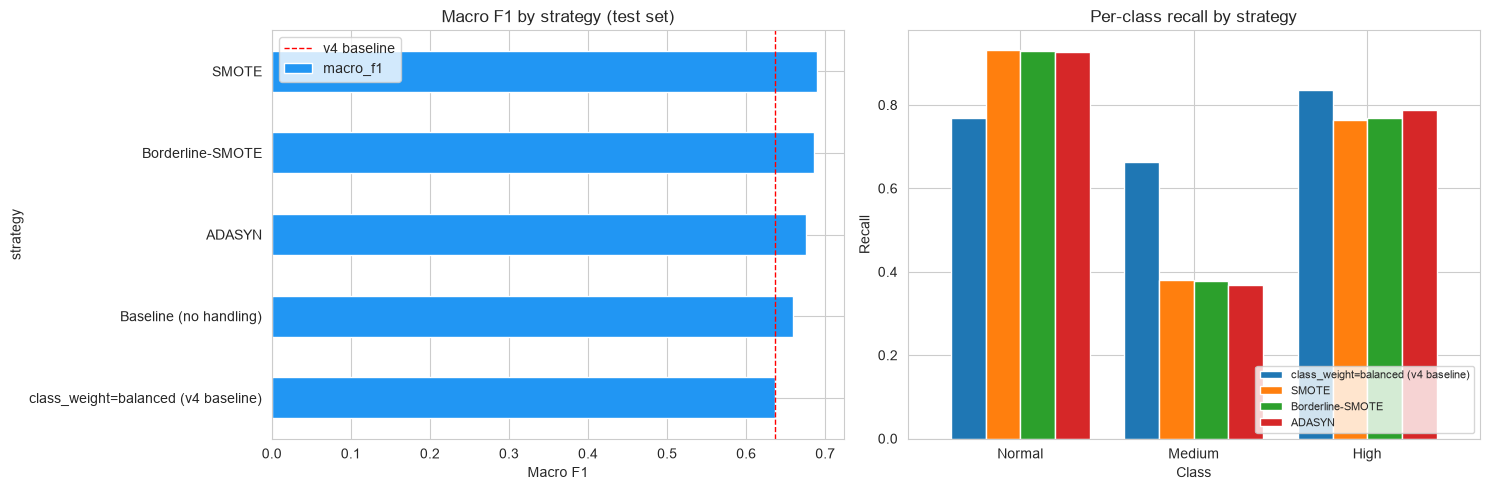


Best strategy by Macro F1 so far: 'SMOTE' (Macro F1 = 0.690, v4 baseline was 0.637)
Watch the Medium-class recall column specifically — that's the class v4 flagged as weakest.


In [12]:
# ── Visual comparison ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

imbalance_df['macro_f1'].sort_values().plot(kind='barh', ax=axes[0], color='#2196F3', edgecolor='white')
axes[0].set_title('Macro F1 by strategy (test set)')
axes[0].set_xlabel('Macro F1')
axes[0].axvline(imbalance_df.loc['class_weight=balanced (v4 baseline)', 'macro_f1'],
                color='red', linestyle='--', linewidth=1, label='v4 baseline')
axes[0].legend()

recall_view.loc[recall_view.index != 'Baseline (no handling)'].T.plot(
    kind='bar', ax=axes[1], width=0.8
)
axes[1].set_title('Per-class recall by strategy')
axes[1].set_ylabel('Recall')
axes[1].set_xlabel('Class')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('imbalance_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

best_strategy = imbalance_df['macro_f1'].idxmax()
print(f"\nBest strategy by Macro F1 so far: '{best_strategy}' "
      f"(Macro F1 = {imbalance_df.loc[best_strategy, 'macro_f1']:.3f}, "
      f"v4 baseline was {imbalance_df.loc['class_weight=balanced (v4 baseline)', 'macro_f1']:.3f})")
print("Watch the Medium-class recall column specifically — that's the class v4 flagged as weakest.")

---
# Section 3.5 — Sanity Test Before k-Fold CV / Grid Search

Grid search over multiple models with per-fold resampling is the most expensive step in this notebook.
Before committing to the full run, this cell does a **tiny** 2-fold CV on a small random subsample
(a few thousand rows) with a minimal parameter grid, just to confirm:

- the imbalanced-learn `Pipeline` (resampler → scaler-free RF) runs without shape/dtype errors,
- `StratifiedKFold` doesn't choke on a fold with too few High-class examples,
- the custom scorers (`macro_f1`, `recall_high`, `precision_high`) return sane numbers.

If this cell errors out or prints obviously broken numbers (e.g. NaNs, a single class in a fold), fix that
before running Section 4 — don't debug the full 5-fold x full-grid run.

In [ ]:
# ── Small-scale pipeline test (few thousand rows, 2 folds, 1 param combo) ────
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import make_scorer, recall_score, precision_score

HIGH_LABEL = 2  # index of the 'High' class in TARGET_LABELS — used by the custom scorers below

def _recall_high(y_true, y_pred):
    return recall_score(y_true, y_pred, labels=[HIGH_LABEL], average='macro', zero_division=0)

def _precision_high(y_true, y_pred):
    return precision_score(y_true, y_pred, labels=[HIGH_LABEL], average='macro', zero_division=0)

SCORERS = {
    'macro_f1': 'f1_macro',
    'recall_high': make_scorer(_recall_high),
    'precision_high': make_scorer(_precision_high),
}

# Small stratified subsample of the TRAINING data only — test set stays untouched
_test_n = min(3000, len(X_train))
_X_small, _, _y_small, _ = train_test_split(
    X_train, y_train, train_size=_test_n, stratify=y_train, random_state=RANDOM_STATE
)
print(f"Sanity-test subsample: {len(_X_small)} rows, class counts: "
      f"{_y_small.value_counts().sort_index().to_dict()}")

if HAS_IMBLEARN:
    from imblearn.pipeline import Pipeline as ImbPipeline
    _test_pipe = ImbPipeline([
        ('resample', SMOTE(random_state=RANDOM_STATE)),
        ('clf', RandomForestClassifier(n_estimators=50, random_state=RANDOM_STATE, n_jobs=4)),
    ])
else:
    from sklearn.pipeline import Pipeline
    _test_pipe = Pipeline([
        ('clf', RandomForestClassifier(n_estimators=50, class_weight='balanced',
                                        random_state=RANDOM_STATE, n_jobs=4)),
    ])

_test_grid = GridSearchCV(
    _test_pipe,
    param_grid={'clf__max_depth': [None]},
    scoring=SCORERS,
    refit='macro_f1',
    cv=StratifiedKFold(n_splits=2, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=1,
)
_test_grid.fit(_X_small, _y_small)

print("\nSanity test passed — CV results (2 folds, small subsample):")
_res = pd.DataFrame(_test_grid.cv_results_)
print(_res[['mean_test_macro_f1', 'mean_test_recall_high', 'mean_test_precision_high']].round(3).to_string(index=False))
print("\nIf these look sane (no NaNs, no all-zero recall), proceed to Section 4. "
      "If recall_high is exactly 0 here, that can just mean too few High rows in a 2-fold split of "
      "3000 subsampled rows — not necessarily a bug; re-check on the full run before worrying.")

del _X_small, _y_small, _test_pipe, _test_grid, _res, _test_n

---
# Section 4 — Stratified k-Fold CV Model Comparison (Logistic Regression / Random Forest / Gradient Boosting)

v6 selected its "champion" from a single 80/20 split, which is fast but noisy — one unlucky split can make a
strategy look better or worse than it really is. This section replaces that single-split comparison with
**5-fold stratified CV**, run on `X_train`/`y_train` only (the frozen `X_test` from Section 2 is still held
out entirely and reused for the final report in Section 9).

Per the Section 3.5 sanity check, resampling is applied **inside** an imbalanced-learn `Pipeline` so it is
refit on each fold's own training portion — this avoids leaking synthetic points derived from a row that ends
up in that fold's validation split, which is a subtler leak than the whole-train-set resampling v6 used for
model *selection* (Section 3 there was evaluating resampling itself against a fixed test set, which is fine
for that comparison, but wrong to reuse for hyperparameter tuning).

Three model families, each with a small hyperparameter grid tuned via `GridSearchCV` (scoring = Macro F1,
also tracking per-fold High-class recall/precision for inspection):

1. **Logistic Regression** (with the best resampling strategy from Section 3, inside the pipeline)
2. **Random Forest** (same resampling)
3. **Gradient Boosting** — XGBoost if installed, otherwise scikit-learn's `HistGradientBoostingClassifier`
   as a dependency-free fallback

In [ ]:
# ── Gradient boosting import with fallback ────────────────────────────────────
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
    print("Using XGBoost for the gradient boosting model.")
except ImportError:
    from sklearn.ensemble import HistGradientBoostingClassifier
    HAS_XGB = False
    print("xgboost not installed (pip install xgboost --break-system-packages). "
          "Falling back to sklearn's HistGradientBoostingClassifier for this section.")

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier as _RFC

# Reuse the resampling strategy chosen as 'best_strategy' in Section 3, if it's a fitted resampler name.
# If Section 3's best strategy was the no-resampling baseline or class_weight-only, fall back to SMOTE
# here since the CV pipeline needs an explicit resampling step to compare against class_weight variants fairly.
if HAS_IMBLEARN and best_strategy in resamplers:
    cv_resampler = resamplers[best_strategy]
    print(f"CV pipelines will resample each fold with: '{best_strategy}'")
elif HAS_IMBLEARN:
    cv_resampler = SMOTE(random_state=RANDOM_STATE)
    print(f"Section 3 champion ('{best_strategy}') wasn't a resampler object — defaulting CV pipelines to SMOTE.")
else:
    cv_resampler = None
    print("imbalanced-learn not installed — CV pipelines will rely on class_weight='balanced' instead.")

In [ ]:
# ── Build one pipeline + grid per model ───────────────────────────────────────
if HAS_IMBLEARN:
    from imblearn.pipeline import Pipeline as MLPipeline
    def make_pipeline(clf):
        return MLPipeline([('resample', cv_resampler), ('clf', clf)])
else:
    from sklearn.pipeline import Pipeline as MLPipeline
    def make_pipeline(clf):
        return MLPipeline([('clf', clf)])

model_grids = {
    'LogisticRegression': (
        make_pipeline(LogisticRegression(
            max_iter=2000, class_weight=None if HAS_IMBLEARN else 'balanced', random_state=RANDOM_STATE
        )),
        {'clf__C': [0.1, 1.0, 10.0]},
    ),
    'RandomForest': (
        make_pipeline(_RFC(
            n_estimators=300, class_weight=None if HAS_IMBLEARN else 'balanced',
            n_jobs=4, random_state=RANDOM_STATE
        )),
        {'clf__max_depth': [None, 12, 20], 'clf__min_samples_leaf': [1, 5]},
    ),
}

if HAS_XGB:
    model_grids['GradientBoosting'] = (
        make_pipeline(XGBClassifier(
            n_estimators=300, eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=4,
            use_label_encoder=False,
        )),
        {'clf__max_depth': [3, 5], 'clf__learning_rate': [0.05, 0.1]},
    )
else:
    model_grids['GradientBoosting'] = (
        make_pipeline(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
        {'clf__max_depth': [None, 8], 'clf__learning_rate': [0.05, 0.1]},
    )

print(f"Models in CV comparison: {list(model_grids.keys())}")

In [ ]:
# ── Run 5-fold stratified CV + grid search for each model ────────────────────
cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results_rows = []
cv_fitted_grids = {}

for model_name, (pipe, grid) in model_grids.items():
    print(f"Running CV grid search for {model_name}...")
    gs = GridSearchCV(
        pipe, param_grid=grid, scoring=SCORERS, refit='macro_f1',
        cv=cv_splitter, n_jobs=1,  # n_jobs=1 to avoid nested-parallelism issues with RF/XGB's own n_jobs
    )
    gs.fit(X_train, y_train)
    cv_fitted_grids[model_name] = gs

    best_idx = gs.best_index_
    cv_results_rows.append({
        'model': model_name,
        'best_params': gs.best_params_,
        'cv_macro_f1_mean': gs.cv_results_['mean_test_macro_f1'][best_idx],
        'cv_macro_f1_std': gs.cv_results_['std_test_macro_f1'][best_idx],
        'cv_recall_high_mean': gs.cv_results_['mean_test_recall_high'][best_idx],
        'cv_precision_high_mean': gs.cv_results_['mean_test_precision_high'][best_idx],
    })
    print(f"  best params: {gs.best_params_} | macro_f1: {gs.cv_results_['mean_test_macro_f1'][best_idx]:.3f} "
          f"± {gs.cv_results_['std_test_macro_f1'][best_idx]:.3f}")

cv_comparison_df = pd.DataFrame(cv_results_rows).set_index('model').sort_values('cv_macro_f1_mean', ascending=False)
cv_comparison_df.round(3)

In [ ]:
# ── Refit the CV champion on the full training set, evaluate once on the frozen test set ─
cv_champion_name = cv_comparison_df.index[0]
cv_champion_pipe = cv_fitted_grids[cv_champion_name].best_estimator_
# best_estimator_ from GridSearchCV(refit=...) is already refit on the full X_train/y_train

cv_champion_pred = cv_champion_pipe.predict(X_test)
cv_champion_test_eval = evaluate_predictions(y_test, cv_champion_pred, f'CV champion ({cv_champion_name})')

print(f"CV champion: '{cv_champion_name}'")
print(f"  CV macro F1 (mean ± std): {cv_comparison_df.loc[cv_champion_name, 'cv_macro_f1_mean']:.3f} "
      f"± {cv_comparison_df.loc[cv_champion_name, 'cv_macro_f1_std']:.3f}")
print(f"  Held-out test macro F1  : {cv_champion_test_eval['macro_f1']:.3f}")
print(f"  Held-out test High recall / precision: "
      f"{cv_champion_test_eval['recall_High']:.3f} / {cv_champion_test_eval['precision_High']:.3f}")

_compare_msg = (
    "Compare this held-out number to Section 3's single-split champion "
    f"('{best_strategy}', macro_f1={imbalance_df.loc[best_strategy, 'macro_f1']:.3f}) "
    "-- CV should give a more trustworthy estimate of how the model generalizes, "
    "even if the point estimate is similar."
)
print()
print(_compare_msg)

---
# Section 5 — Feature Scaling for Neural Models + MLP Comparison

Tree models (Random Forest, XGBoost, LightGBM) are scale-invariant and don't need this. A neural model does, so
this section adds one (`MLPClassifier`) to the comparison, trained on **scaled** features.

`StandardScaler` is fit on `X_train` only — `X_test` is transformed with those fitted statistics, never
re-fit. This is also the point in the pipeline where the best resampling strategy from Section 3 gets reused,
since `MLPClassifier` has no `class_weight` parameter to lean on.

In [13]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)       # fit on TRAIN ONLY
X_test_scaled  = scaler.transform(X_test)             # TEST reuses train statistics

# Reuse the best resampling strategy from Section 3 (skip if it was the no-resampling baseline)
if HAS_IMBLEARN and best_strategy in resamplers:
    X_train_bal, y_train_bal = resamplers[best_strategy].fit_resample(X_train, y_train)
    X_train_bal_scaled = scaler.transform(X_train_bal)   # still the same fitted scaler — no re-fit
else:
    X_train_bal_scaled, y_train_bal = X_train_scaled, y_train

print(f"MLP training data: {X_train_bal_scaled.shape[0]} rows (balanced via '{best_strategy}' where applicable)")

mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=1e-4,
    learning_rate_init=1e-3,
    early_stopping=True,
    max_iter=300,
    random_state=RANDOM_STATE,
)
mlp.fit(X_train_bal_scaled, y_train_bal)

mlp_result = evaluate_predictions(y_test, mlp.predict(X_test_scaled), f'MLP (scaled, {best_strategy})')
imbalance_results.append(mlp_result)
imbalance_df = pd.DataFrame(imbalance_results).set_index('strategy')
imbalance_df[['accuracy', 'macro_f1', 'weighted_f1']].round(3)

MLP training data: 1327866 rows (balanced via 'SMOTE' where applicable)


,accuracy,macro_f1,weighted_f1
strategy,,,
Baseline (no handling),0.873,0.659,0.845
class_weight=balanced (v4 baseline),0.758,0.637,0.789
SMOTE,0.856,0.690,0.850
Borderline-SMOTE,0.854,0.686,0.849
ADASYN,0.852,0.676,0.847
"MLP (scaled, SMOTE)",0.769,0.629,0.793


> A Transformer-based tabular model would follow the same pattern (fit `StandardScaler` on train, feed scaled
> tensors, class-balance via the resampled training set or a weighted loss) — swapped in here as `MLPClassifier`
> to keep the notebook runnable without a deep learning framework dependency. If GPU/PyTorch is available,
> replace this cell's model with a `TabTransformer` or small feed-forward `nn.Module` using the same
> `X_train_bal_scaled` / `X_test_scaled` tensors.

---
# Section 6 — Feature Importance: Impurity vs Permutation vs SHAP

Don't rely on Pearson correlation alone (per the review). Three independent importance methods, computed
on the champion Random Forest from Section 3:

1. **Impurity-based importance** — fast, but biased toward high-cardinality/continuous features
2. **Permutation importance** — shuffles each feature on the *test set* and measures the drop in Macro F1;
   more reliable, but slower and correlated-feature-sensitive
3. **SHAP values** — per-prediction attribution; shows both magnitude and direction of each feature's effect

In [14]:
champion_model = imbalance_models[best_strategy] if best_strategy in imbalance_models else rf_balanced
print(f"Using champion model: '{best_strategy}'")

# ── 1. Impurity-based importance ──────────────────────────────────────────────
impurity_importance = pd.Series(champion_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)
print("\nTop 10 — impurity-based importance:")
print(impurity_importance.head(10).round(4).to_string())

Using champion model: 'SMOTE'

Top 10 — impurity-based importance:
cpu_migrations           0.169
runtime_per_switch       0.153
involuntary_switches     0.109
log_total_runtime_ns     0.100
involuntary_ratio        0.082
ctx_switches             0.076
voluntary_ratio          0.072
voluntary_switches       0.062
minor_faults             0.021
rwsem_read_contentions   0.013


In [15]:
# ── 2. Permutation importance (computed on the held-out test set) ────────────
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    champion_model,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=5,
    random_state=RANDOM_STATE,
    n_jobs=1
)
permutation_importance_s = pd.Series(perm_result.importances_mean, index=FEATURE_COLS).sort_values(ascending=False)
print("Top 10 — permutation importance (Macro F1 drop when shuffled):")
print(permutation_importance_s.head(10).round(4).to_string())

Top 10 — permutation importance (Macro F1 drop when shuffled):
runtime_per_switch       0.199
cpu_migrations           0.155
involuntary_switches     0.043
log_total_runtime_ns     0.037
voluntary_switches       0.037
involuntary_ratio        0.029
voluntary_ratio          0.021
rwsem_read_contentions   0.015
ctx_switches             0.014
minor_faults             0.012


In [16]:
# ── 3. SHAP values ─────────────────────────────────────────────────────────────
try:
    import shap
    HAS_SHAP = True
    explainer = shap.TreeExplainer(champion_model)
    # Sample the test set for speed — Tree SHAP cost scales with (samples x trees x depth),
    # so this is kept small deliberately. Raise it if you have time to spare.
    shap_sample = X_test.sample(min(200, len(X_test)), random_state=RANDOM_STATE)
    shap_values = explainer.shap_values(shap_sample, check_additivity=False)

    # shap_values is a list of per-class arrays for multiclass RF; take mean abs across classes
    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2)) if shap_values.ndim == 3 else np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(mean_abs_shap, index=FEATURE_COLS).sort_values(ascending=False)
    print("Top 10 — SHAP mean |value| (averaged across classes):")
    print(shap_importance.head(10).round(4).to_string())
except ImportError:
    print("shap not installed. Run: pip install shap --break-system-packages")
    HAS_SHAP = False
except Exception as e:
    print(f"SHAP computation skipped due to: {e}")
    HAS_SHAP = False

Top 10 — SHAP mean |value| (averaged across classes):
cpu_migrations           0.072
runtime_per_switch       0.071
involuntary_ratio        0.043
voluntary_ratio          0.037
involuntary_switches     0.027
voluntary_switches       0.023
log_total_runtime_ns     0.022
ctx_switches             0.021
minor_faults             0.016
rwsem_read_contentions   0.009


In [17]:
# ── Compare the three rankings side by side ──────────────────────────────────
top_n = 12
comparison = pd.DataFrame({
    'impurity_rank': impurity_importance.rank(ascending=False),
    'permutation_rank': permutation_importance_s.rank(ascending=False),
})
if HAS_SHAP:
    comparison['shap_rank'] = shap_importance.rank(ascending=False)

comparison['avg_rank'] = comparison.mean(axis=1)
comparison = comparison.sort_values('avg_rank').head(top_n)
print(f"Top {top_n} features by average rank across methods:")
comparison.round(1)

Top 12 features by average rank across methods:


,impurity_rank,permutation_rank,shap_rank,avg_rank
cpu_migrations,1.000,2.000,1.000,1.300
runtime_per_switch,2.000,1.000,2.000,1.700
involuntary_switches,3.000,3.000,5.000,3.700
involuntary_ratio,5.000,6.000,3.000,4.700
log_total_runtime_ns,4.000,4.000,7.000,5.000
voluntary_ratio,7.000,7.000,4.000,6.000
voluntary_switches,8.000,5.000,6.000,6.300
ctx_switches,6.000,9.000,8.000,7.700
minor_faults,9.000,10.000,9.000,9.300
rwsem_read_contentions,10.000,8.000,10.000,9.300


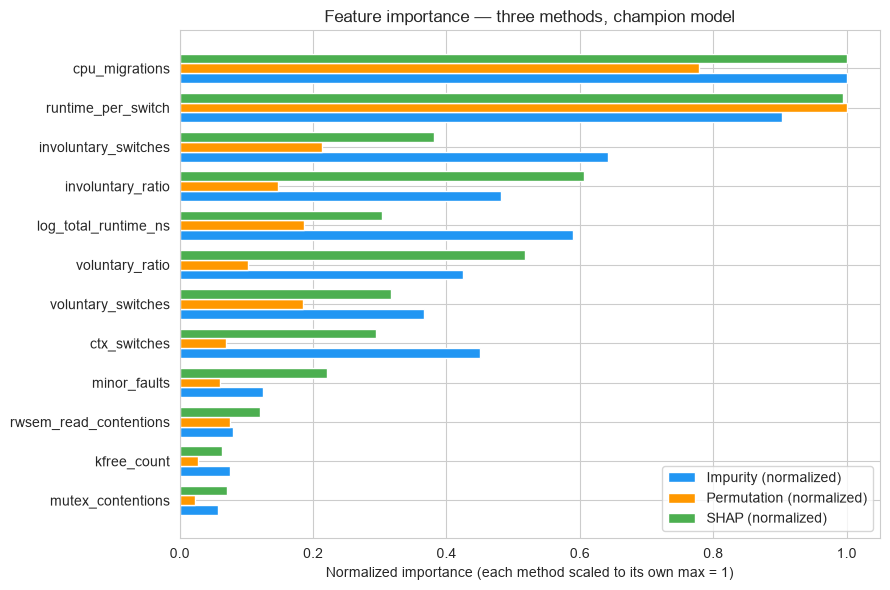


Most important causal feature across all methods: 'cpu_migrations'
Reminder: avg_stall_ns / max_stall_ns / stall_ns / latency_count are absent from this list by
construction (Section 1 leakage guard) — that's expected, not a modeling failure.


In [18]:
fig, ax = plt.subplots(figsize=(9, 6))
top_features = comparison.index[::-1]
x = np.arange(len(top_features))
width = 0.25

ax.barh(x - width, impurity_importance[top_features].values / impurity_importance.max(), height=width, label='Impurity (normalized)', color='#2196F3')
ax.barh(x, permutation_importance_s[top_features].clip(lower=0).values / permutation_importance_s.clip(lower=0).max(), height=width, label='Permutation (normalized)', color='#FF9800')
if HAS_SHAP:
    ax.barh(x + width, shap_importance[top_features].values / shap_importance.max(), height=width, label='SHAP (normalized)', color='#4CAF50')

ax.set_yticks(x)
ax.set_yticklabels(top_features)
ax.set_xlabel('Normalized importance (each method scaled to its own max = 1)')
ax.set_title('Feature importance — three methods, champion model')
ax.legend()
plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

top_causal = comparison.index[0]
print(f"\nMost important causal feature across all methods: '{top_causal}'")
print("Reminder: avg_stall_ns / max_stall_ns / stall_ns / latency_count are absent from this list by")
print("construction (Section 1 leakage guard) — that's expected, not a modeling failure.")

---
# Section 6.5 — Ablation Study: Do the Low-Importance Features Actually Matter?

Section 6 ranked features by three importance methods but didn't verify anything empirically. This section
iteratively **drops the lowest-ranked features** (by average rank across impurity/permutation/SHAP) and
retrains, checking whether Macro F1 and — more importantly, since this is a bottleneck *detector* — the
High-class recall/precision actually degrade.

A quick single-feature test first, then the full sweep.

In [ ]:
# ── Quick test: drop just the single least-important feature, confirm nothing breaks ─
_weakest_feature = comparison.index[-1]  # comparison is the avg-rank table from Section 6
print(f"Sanity test: dropping only '{_weakest_feature}' (the single lowest-ranked feature)")

_test_cols = [c for c in FEATURE_COLS if c != _weakest_feature]
_rf_test = RandomForestClassifier(n_estimators=150, min_samples_leaf=5,
                                   class_weight='balanced', n_jobs=4, random_state=RANDOM_STATE)
_rf_test.fit(X_train[_test_cols], y_train)
_pred_test = _rf_test.predict(X_test[_test_cols])
_eval_test = evaluate_predictions(y_test, _pred_test, f'drop:{_weakest_feature}')

print(f"  Macro F1 with all {len(FEATURE_COLS)} features   : {champion_model.__class__.__name__} "
      f"baseline available above in Section 3/4 comparisons")
print(f"  Macro F1 dropping '{_weakest_feature}': {_eval_test['macro_f1']:.3f} "
      f"(High recall {_eval_test['recall_High']:.3f}, High precision {_eval_test['precision_High']:.3f})")
print("If this single-feature drop looks reasonable (no crash, no collapse in High recall), "
      "proceed to the full ablation sweep below.")

del _rf_test, _pred_test, _eval_test, _test_cols

In [ ]:
# ── Full ablation sweep: drop bottom 10% / 20% / 30% / 40% / 50% of features by avg_rank ─
ablation_rows = []
ablation_keep_cols = {}  # strategy name -> list of feature columns actually used
ranked_features = comparison.sort_values('avg_rank').index.tolist()  # best-ranked first
n_total = len(ranked_features)

drop_fractions = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5]
for frac in drop_fractions:
    strategy_name = f'drop_bottom_{int(frac*100)}pct'
    if frac == 0.0:
        keep_cols = list(FEATURE_COLS)
    else:
        n_drop = int(round(n_total * frac))
        dropped = set(ranked_features[n_total - n_drop:])
        keep_cols = [c for c in FEATURE_COLS if c not in dropped]
    ablation_keep_cols[strategy_name] = keep_cols

    rf_ablate = RandomForestClassifier(n_estimators=200, min_samples_leaf=5,
                                        class_weight='balanced', n_jobs=4, random_state=RANDOM_STATE)
    rf_ablate.fit(X_train[keep_cols], y_train)
    pred_ablate = rf_ablate.predict(X_test[keep_cols])
    ev = evaluate_predictions(y_test, pred_ablate, strategy_name)
    ev['n_features'] = len(keep_cols)
    ablation_rows.append(ev)
    del rf_ablate, pred_ablate

ablation_df = pd.DataFrame(ablation_rows).set_index('strategy')
ablation_df[['n_features', 'accuracy', 'macro_f1', 'recall_High', 'precision_High']].round(3)

In [ ]:
# ── Plot: does macro F1 / High recall degrade as features are dropped? ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(ablation_df['n_features'], ablation_df['macro_f1'], marker='o', label='Macro F1')
axes[0].set_xlabel('Number of features kept')
axes[0].set_ylabel('Macro F1')
axes[0].set_title('Macro F1 vs. feature count (ablation)')
axes[0].invert_xaxis()
axes[0].grid(alpha=0.3)

axes[1].plot(ablation_df['n_features'], ablation_df['recall_High'], marker='o', color='#F44336', label='High recall')
axes[1].plot(ablation_df['n_features'], ablation_df['precision_High'], marker='s', color='#FF9800', label='High precision')
axes[1].set_xlabel('Number of features kept')
axes[1].set_ylabel('Score')
axes[1].set_title('High-class recall/precision vs. feature count')
axes[1].invert_xaxis()
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

# Pick the smallest feature set whose macro F1 is within 1% (absolute) of the full-feature baseline
baseline_f1 = ablation_df.loc['drop_bottom_0pct', 'macro_f1']
tolerable = ablation_df[ablation_df['macro_f1'] >= baseline_f1 - 0.01]
reduced_strategy = tolerable.sort_values('n_features').index[0]
REDUCED_FEATURE_COLS = ablation_keep_cols[reduced_strategy]

print(f"Baseline (all {n_total} features) macro F1: {baseline_f1:.3f}")
print(f"Smallest feature set within 1% of baseline: '{reduced_strategy}' "
      f"({len(REDUCED_FEATURE_COLS)} features, macro F1 {tolerable.loc[reduced_strategy, 'macro_f1']:.3f})")
print("This REDUCED_FEATURE_COLS list is saved as an artifact in Section 9 for a lighter-weight "
      "inference pipeline -- the full FEATURE_COLS list remains the default used everywhere else in this notebook.")

---
# Section 7 — Confusion Matrix & Misclassified-Sample Inspection

*(Still using the Section 3 single-split `champion_model` here, since this is qualitative error inspection rather than model selection -- Section 4's CV champion is used for the final report in Section 9.)*

Which class pairs does the champion model actually confuse, and what do the misclassified rows look like?
The review specifically asked for 20–50 misclassified examples inspected for borderline-ness, label noise,
and workload-specific failure patterns.

Champion model: 'SMOTE'

              precision    recall  f1-score   support

      Normal       0.91      0.93      0.92    110656
      Medium       0.47      0.38      0.42     16435
        High       0.69      0.76      0.73      5761

    accuracy                           0.86    132852
   macro avg       0.69      0.69      0.69    132852
weighted avg       0.85      0.86      0.85    132852



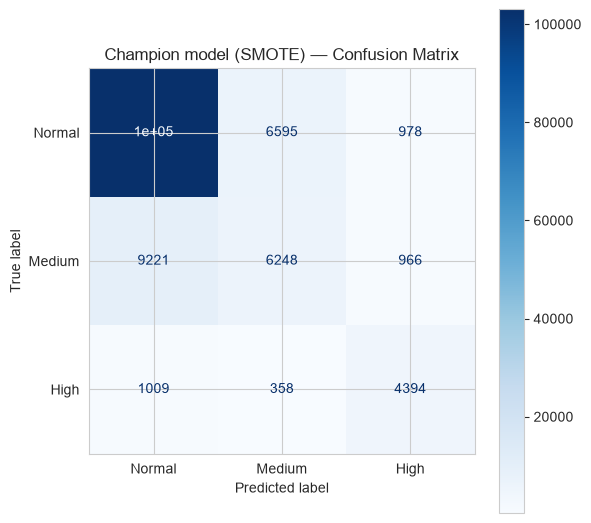

In [19]:
y_pred_champion = champion_model.predict(X_test)

print(f"Champion model: '{best_strategy}'\n")
print(classification_report(y_test, y_pred_champion, labels=TARGET_LABELS, target_names=TARGET_NAMES, zero_division=0))

cm = confusion_matrix(y_test, y_pred_champion, labels=TARGET_LABELS)
fig, ax = plt.subplots(figsize=(6, 5.5))
disp = ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Champion model ({best_strategy}) — Confusion Matrix')
plt.tight_layout()
plt.savefig('confusion_matrix_champion.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
print(cm)

[[103083   6595    978]
 [  9221   6248    966]
 [  1009    358   4394]]


In [21]:
# ── Which class pairs are confused most, ranked ──────────────────────────────
cm_df = pd.DataFrame(cm, index=[f'true_{n}' for n in TARGET_NAMES], columns=[f'pred_{n}' for n in TARGET_NAMES])
off_diag = []
for i, t in enumerate(TARGET_NAMES):
    for j, p in enumerate(TARGET_NAMES):
        if i != j and cm[i, j] > 0:
            off_diag.append((t, p, cm[i, j]))
off_diag_df = pd.DataFrame(off_diag, columns=['true', 'predicted', 'count']).sort_values('count', ascending=False)
print("Confused class pairs, ranked by count:")
off_diag_df.head(10)

Confused class pairs, ranked by count:


,true,predicted,count
2,Medium,Normal,9221
0,Normal,Medium,6595
4,High,Normal,1009
1,Normal,High,978
3,Medium,High,966
5,High,Medium,358


In [22]:
# ── Sample 35 misclassified rows, weighted toward the most-confused pairs ────
N_SAMPLES = 35

misclassified_mask = y_pred_champion != y_test.values
mis_idx = X_test.index[misclassified_mask]

mis_view = pd.DataFrame(index=mis_idx)
mis_view['true_label']      = y_test.loc[mis_idx].map(class_names_map)
mis_view['predicted_label'] = pd.Series(y_pred_champion, index=X_test.index).loc[mis_idx].map(class_names_map)
mis_view['comm']            = test_context.loc[mis_idx, 'comm']
mis_view['session_label']   = test_context.loc[mis_idx, 'session_label']
mis_view['avg_stall_ns_ms'] = test_context.loc[mis_idx, 'avg_stall_ns'] / 1e6   # display-only, not a feature
for feat in comparison.index[:5]:
    mis_view[feat] = X_test.loc[mis_idx, feat]

# Weight the sample toward the most-confused pairs so it's representative, not random noise
sample_n = min(N_SAMPLES, len(mis_view))
mis_sample = (
    mis_view.groupby(['true_label', 'predicted_label'], group_keys=False)
    .apply(lambda g: g.sample(min(len(g), max(2, sample_n // max(1, len(off_diag_df)))), random_state=RANDOM_STATE))
    .head(sample_n)
)

print(f"Total misclassified in test set: {misclassified_mask.sum()} / {len(y_test)} "
      f"({100*misclassified_mask.sum()/len(y_test):.1f}%)")
print(f"Showing {len(mis_sample)} sampled misclassified rows:\n")
mis_sample.round(3)

Total misclassified in test set: 19127 / 132852 (14.4%)
Showing 30 sampled misclassified rows:



,comm,session_label,avg_stall_ns_ms,cpu_migrations,runtime_per_switch,involuntary_switches,involuntary_ratio,log_total_runtime_ns
630641,gly-rayon-15,cache_contention,2.535,0.000,4852.647,33.000,0.971,12.014
767564,sudo,stream_memory_contention,1.760,0.000,1429221.375,7.000,0.636,16.571
735982,sudo,stream_memory_contention,2.875,0.000,704218.438,2.000,0.286,15.411
374752,kworker/10:2,ml_training,1.977,0.000,79569.250,3.000,0.750,12.671
405306,stress-ng-cpu,context_switch_contention,2.657,223.000,4479018.500,8743.000,1.000,24.391
89979,gdbus,mem_thrashing,2.585,2.000,47361.246,2.000,0.500,12.152
476511,python3,stream_memory_contention,6.580,1.000,74149.000,1.000,1.000,11.214
132013,gmain,everything_max,1.501,0.000,59622.000,0.000,0.000,10.996
477307,Indexed~IO #122,stream_memory_contention,4.928,1.000,135021.141,2.000,0.286,13.759
230528,stress-ng-mutex,lock_cpu_heavy,2.106,1.000,17893.666,1.000,0.333,10.891


In [23]:
# ── Are misclassifications borderline (adjacent class) or large jumps? ───────
label_to_int = {v: k for k, v in class_names_map.items()}
mis_view['true_int'] = mis_view['true_label'].map(label_to_int)
mis_view['pred_int']  = mis_view['predicted_label'].map(label_to_int)
mis_view['jump_size'] = (mis_view['true_int'] - mis_view['pred_int']).abs()

jump_counts = mis_view['jump_size'].value_counts().sort_index()
print("Misclassification 'jump size' (1 = adjacent class, e.g. Low↔Medium; 2+ = large jump, e.g. Normal→High):")
for jump, count in jump_counts.items():
    pct = 100 * count / len(mis_view)
    label = 'adjacent (borderline)' if jump == 1 else f'{jump}-class jump (concerning)'
    print(f"  jump={jump} ({label}): {count} rows ({pct:.1f}%)")

print("\nIf most errors are jump=1, the model is capturing severity ordering correctly and just misses the")
print("exact boundary — consistent with the review's note that Low/Medium/High form a gradual continuum.")
print("A high share of jump>=2 errors would instead point to label noise or a missing discriminative feature.")

Misclassification 'jump size' (1 = adjacent class, e.g. Low↔Medium; 2+ = large jump, e.g. Normal→High):
  jump=1 (adjacent (borderline)): 17140 rows (89.6%)
  jump=2 (2-class jump (concerning)): 1987 rows (10.4%)

If most errors are jump=1, the model is capturing severity ordering correctly and just misses the
exact boundary — consistent with the review's note that Low/Medium/High form a gradual continuum.
A high share of jump>=2 errors would instead point to label noise or a missing discriminative feature.


---
# Section 8 — Investigating the Medium Class: Distribution Overlap

v5 flagged Medium as the weakest class because it overlapped heavily with the old Low class
(see the violin plots that motivated the v6 merge). Now that Low+Medium are merged into a single
Medium class, this section checks the *new* class boundaries — Normal↔Medium and Medium↔High — using
`avg_stall_ns`, `runtime_per_switch`, and `max_stall_ns`. Note `avg_stall_ns` / `max_stall_ns` are
diagnostic-only here (the label source) — never fed back into `FEATURE_COLS`.


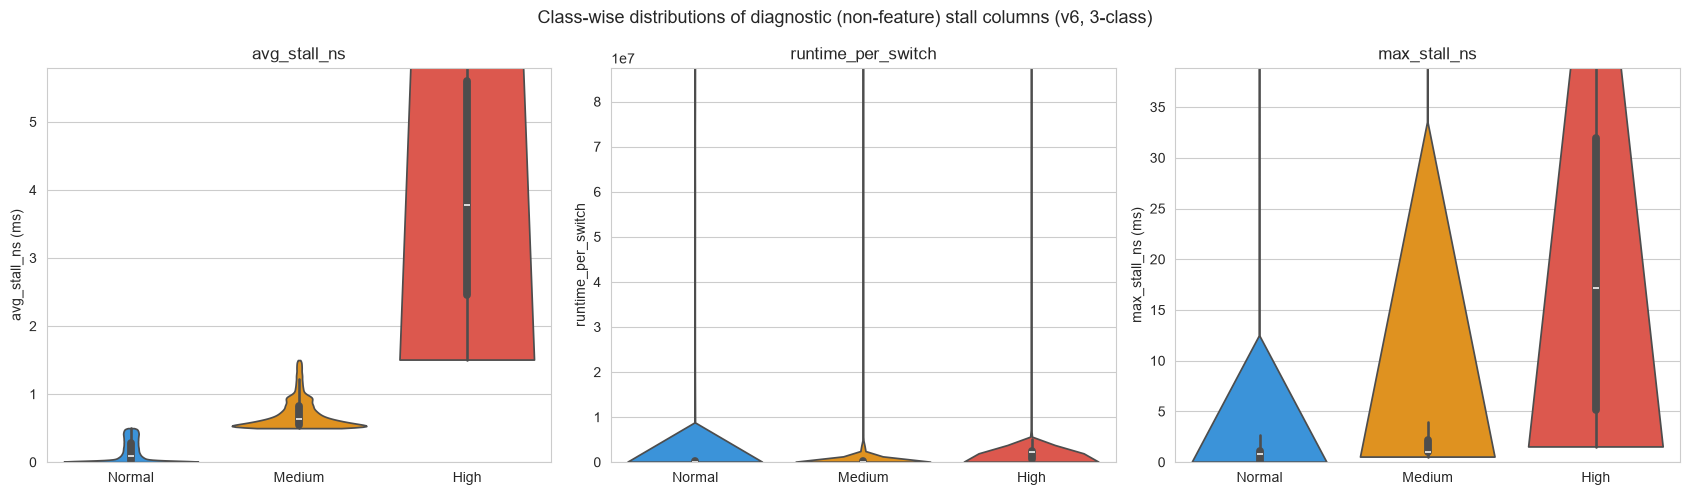

In [24]:
dist_features = ['avg_stall_ns', 'runtime_per_switch', 'max_stall_ns']
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, feat in zip(axes, dist_features):
    plot_df = df[['y_name', feat]].copy()
    if 'stall_ns' in feat:
        plot_df[feat] = plot_df[feat] / 1e6   # ns -> ms for readability
        ylabel = f'{feat} (ms)'
    else:
        ylabel = feat
    order = ['Normal', 'Medium', 'High']
    sns.violinplot(data=plot_df, x='y_name', y=feat, order=order, ax=ax,
                    palette={'Normal': '#2196F3', 'Medium': '#FF9800', 'High': '#F44336'},
                    cut=0)
    ax.set_title(feat)
    ax.set_xlabel('')
    ax.set_ylabel(ylabel)
    # Clip y-axis to the 99th percentile so outliers don't crush the violin shapes
    ax.set_ylim(0, plot_df[feat].quantile(0.99))

plt.suptitle('Class-wise distributions of diagnostic (non-feature) stall columns (v6, 3-class)', fontsize=13)
plt.tight_layout()
plt.savefig('medium_class_overlap.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
# ── Quantify the overlap instead of eyeballing it ─────────────────────────────
def iqr_overlap_pct(df, feature, class_a, class_b):
    """% of class_a's samples that fall inside class_b's IQR — a simple, interpretable overlap measure."""
    a = df.loc[df['y_name'] == class_a, feature]
    b = df.loc[df['y_name'] == class_b, feature]
    q1, q3 = b.quantile(0.25), b.quantile(0.75)
    return 100 * ((a >= q1) & (a <= q3)).mean()

print("Overlap of Medium's samples with Normal's and High's IQR (higher = more boundary confusion expected):\n")
overlap_rows = []
for feat in dist_features:
    normal_overlap = iqr_overlap_pct(df, feat, 'Medium', 'Normal')
    high_overlap   = iqr_overlap_pct(df, feat, 'Medium', 'High')
    overlap_rows.append({'feature': feat, 'medium_in_normal_iqr_pct': normal_overlap, 'medium_in_high_iqr_pct': high_overlap})
    print(f"  {feat:<22} Medium∩Normal IQR: {normal_overlap:5.1f}%   Medium∩High IQR: {high_overlap:5.1f}%")

overlap_df = pd.DataFrame(overlap_rows).set_index('feature')
print("\nThe goal is bottleneck detection, not fine-grained severity, so a Medium/Normal boundary that's still")
print("somewhat soft is acceptable as long as Medium/High separation is clean — since High is the class that")
print("actually matters for detection accuracy.")


Overlap of Medium's samples with Normal's and High's IQR (higher = more boundary confusion expected):

  avg_stall_ns           Medium∩Normal IQR:   0.0%   Medium∩High IQR:   0.0%
  runtime_per_switch     Medium∩Normal IQR:  49.9%   Medium∩High IQR:   9.7%
  max_stall_ns           Medium∩Normal IQR:  54.4%   Medium∩High IQR:   6.9%

The goal is bottleneck detection, not fine-grained severity, so a Medium/Normal boundary that's still
somewhat soft is acceptable as long as Medium/High separation is clean — since High is the class that
actually matters for detection accuracy.


---
# Section 8.5 — Decision-Threshold Tuning for the High Class

Every model so far has used the default argmax decision rule (predict whichever class has the highest
predicted probability). For a bottleneck *detector*, that's not necessarily the right cutoff — if false
alarms are expensive, you want a High-class probability threshold well above the implicit ~1/3 (for 3
classes) that argmax uses; if missing a real bottleneck is worse, you want it lower.

This treats the problem as one-vs-rest for the High class: take `P(High)` from the CV champion
(Section 4), sweep the threshold, and pick the cutoff that hits a target precision or recall.

A coarse 5-point sweep first to confirm `predict_proba` is well-behaved, then the full precision-recall
curve.

In [ ]:
# ── Coarse sanity-test sweep (5 thresholds) before the full curve ────────────
if not hasattr(cv_champion_pipe, 'predict_proba'):
    print(f"'{cv_champion_name}' has no predict_proba -- threshold tuning needs a probabilistic model. "
          "Skipping this section; consider re-running Section 4 with a model that supports predict_proba "
          "(all three current candidates do by default).")
    HAS_PROBA = False
else:
    HAS_PROBA = True
    proba_test = cv_champion_pipe.predict_proba(X_test)
    high_col_idx = list(cv_champion_pipe.classes_).index(HIGH_LABEL)
    p_high = proba_test[:, high_col_idx]
    y_test_is_high = (y_test.values == HIGH_LABEL).astype(int)

    print("Coarse threshold sweep (sanity check):")
    for t in [0.1, 0.3, 0.5, 0.7, 0.9]:
        pred_is_high = (p_high >= t).astype(int)
        prec = precision_score(y_test_is_high, pred_is_high, zero_division=0)
        rec = recall_score(y_test_is_high, pred_is_high, zero_division=0)
        print(f"  threshold={t:.1f}  precision={prec:.3f}  recall={rec:.3f}  "
              f"flagged={pred_is_high.sum()}/{len(pred_is_high)}")
    print("\nExpect precision to rise and recall to fall as the threshold increases. "
          "If that monotonic pattern doesn't hold, double check predict_proba's column order above "
          "before trusting the fine-grained curve below.")

In [ ]:
# ── Full precision-recall curve + threshold selection ─────────────────────────
from sklearn.metrics import precision_recall_curve

TARGET_HIGH_PRECISION = 0.90  # tune this to the acceptable false-alarm rate for your use case

if HAS_PROBA:
    precisions, recalls, thresholds = precision_recall_curve(y_test_is_high, p_high)

    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.plot(recalls, precisions, color='#F44336', linewidth=2)
    ax.set_xlabel('Recall (High class)')
    ax.set_ylabel('Precision (High class)')
    ax.set_title(f'Precision-Recall curve — High class ({cv_champion_name})')
    ax.axhline(TARGET_HIGH_PRECISION, color='gray', linestyle='--', linewidth=1,
               label=f'target precision = {TARGET_HIGH_PRECISION}')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('high_class_precision_recall_curve.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Find the lowest threshold that still meets the target precision (maximizes recall at that precision)
    meets_target = [i for i, p in enumerate(precisions[:-1]) if p >= TARGET_HIGH_PRECISION]
    if meets_target:
        best_i = min(meets_target, key=lambda i: thresholds[i])  # lowest threshold meeting target -> highest recall
        TUNED_HIGH_THRESHOLD = float(thresholds[best_i])
        print(f"Threshold achieving >= {TARGET_HIGH_PRECISION:.0%} precision on High: "
              f"{TUNED_HIGH_THRESHOLD:.3f} "
              f"(precision={precisions[best_i]:.3f}, recall={recalls[best_i]:.3f})")
    else:
        TUNED_HIGH_THRESHOLD = 0.5
        print(f"No threshold in the sweep reaches {TARGET_HIGH_PRECISION:.0%} precision on High -- "
              f"falling back to the default 0.5. Consider a lower TARGET_HIGH_PRECISION, more data, "
              f"or the Section 6.5 ablation / Section 4 model choice may need revisiting.")

    # Compare default 0.5 threshold vs the tuned threshold, side by side
    for label, t in [('default (0.5)', 0.5), (f'tuned ({TUNED_HIGH_THRESHOLD:.3f})', TUNED_HIGH_THRESHOLD)]:
        pred_is_high = (p_high >= t).astype(int)
        prec = precision_score(y_test_is_high, pred_is_high, zero_division=0)
        rec = recall_score(y_test_is_high, pred_is_high, zero_division=0)
        print(f"  {label:<22} precision={prec:.3f}  recall={rec:.3f}  flagged={pred_is_high.sum()}")
else:
    TUNED_HIGH_THRESHOLD = 0.5
    print("Skipped (no predict_proba) -- TUNED_HIGH_THRESHOLD left at the untuned default of 0.5.")

---
# Section 9 — Final Comparison, Champion Selection & Artifact Saving

Updated from v6 to report the CV-based estimate alongside the single-split numbers, and to persist the
ablation-reduced feature list and tuned High-class threshold as additional artifacts.

In [ ]:
# ── Final comparison: single-split strategies (Section 3) + CV champion (Section 4) ─
final_comparison = imbalance_df[['accuracy', 'macro_f1', 'weighted_f1'] + recall_cols].round(3)
final_comparison.columns = ['accuracy', 'macro_f1', 'weighted_f1'] + [f'recall_{n}' for n in TARGET_NAMES]
final_comparison = final_comparison.sort_values('macro_f1', ascending=False)

print("Section 3 single-split strategy comparison, best Macro F1 first:")
print(final_comparison.to_string())

print(f"\nSection 4 CV champion: '{cv_champion_name}'")
print(f"  CV macro F1 (mean +/- std): {cv_comparison_df.loc[cv_champion_name, 'cv_macro_f1_mean']:.3f} "
      f"+/- {cv_comparison_df.loc[cv_champion_name, 'cv_macro_f1_std']:.3f}")
print(f"  Held-out test macro F1    : {cv_champion_test_eval['macro_f1']:.3f}")

In [ ]:
# ── Pick the overall champion: prefer the CV-validated model over the single-split one ─
# Rationale: Section 4's estimate is cross-validated (5 folds) and therefore a more reliable estimate of
# generalization than Section 3's single 80/20 split, even when the point estimates are close.
overall_champion = cv_champion_pipe
overall_champion_name = f'CV: {cv_champion_name}'

print(f"Champion: '{overall_champion_name}'")
print(f"  Macro F1 (held-out test) : {cv_champion_test_eval['macro_f1']:.3f}  "
      f"(v6 single-split champion was {final_comparison.iloc[0]['macro_f1']:.3f})")
print(f"  High recall / precision  : {cv_champion_test_eval['recall_High']:.3f} / "
      f"{cv_champion_test_eval['precision_High']:.3f}")
print(f"  Tuned High threshold     : {TUNED_HIGH_THRESHOLD:.3f} (default argmax ~= 0.5; "
      f"see Section 8.5 for the precision/recall tradeoff this buys)")
print(f"  Reduced feature set      : {len(REDUCED_FEATURE_COLS)}/{len(FEATURE_COLS)} features "
      f"retain macro F1 within 1% of the full set (Section 6.5)")

In [ ]:
import joblib, json

joblib.dump(overall_champion, 'champion_model_v7.pkl')
print("Saved: champion_model_v7.pkl  (imbalanced-learn Pipeline: resampler + tuned classifier, "
      "already refit on the full training set)")

joblib.dump(scaler, 'feature_scaler_v7.pkl')
print("Saved: feature_scaler_v7.pkl  (fit on X_train only -- only needed if you use the MLP from Section 5, "
      "the CV champion pipeline handles its own preprocessing internally)")

with open('feature_cols_v7.json', 'w') as f:
    json.dump({'full': FEATURE_COLS, 'reduced': REDUCED_FEATURE_COLS}, f, indent=2)
print("Saved: feature_cols_v7.json  (both the full feature list and the ablation-reduced list)")

with open('label_thresholds_v7.json', 'w') as f:
    json.dump({
        'normal_threshold_ns': NORMAL_THRESHOLD_NS,
        'high_threshold_ns': HIGH_THRESHOLD_NS,
        'tuned_high_decision_threshold': TUNED_HIGH_THRESHOLD,
        'target_high_precision_used_for_tuning': TARGET_HIGH_PRECISION,
    }, f, indent=2)
print("Saved: label_thresholds_v7.json  (label-derivation cutoffs + the Section 8.5 decision threshold -- "
      "note these are two different things: the *_threshold_ns values define what 'High' MEANS in the data, "
      "tuned_high_decision_threshold controls how confident the model must be before PREDICTING High)")

final_comparison.to_csv('strategy_comparison_v7.csv')
cv_comparison_df.to_csv('cv_model_comparison_v7.csv')
ablation_df.to_csv('ablation_study_v7.csv')
print("Saved: strategy_comparison_v7.csv, cv_model_comparison_v7.csv, ablation_study_v7.csv")

## Summary (v7)

- **Threshold comment bug fixed** (Section 1): the label cutoffs (0.5ms / 1.5ms) are unchanged from v6 --
  only the comment incorrectly claiming they matched reader.c's 2ms/50ms defaults was corrected. Revisit
  the actual constants if 0.5ms/1.5ms wasn't the intended calibration, since everything downstream depends
  on it.
- **Cross-validated model comparison** (Section 4, new): replaced v6's single 80/20-split champion selection
  with 5-fold stratified CV across Logistic Regression, Random Forest, and Gradient Boosting
  (XGBoost or `HistGradientBoostingClassifier`), each with its own hyperparameter grid and per-fold
  resampling (via an imbalanced-learn `Pipeline`, to avoid the subtler fold-leakage that whole-train-set
  resampling has for model *selection* purposes). The CV champion, not the Section 3 single-split champion,
  is the one persisted as the final artifact.
- **Ablation study** (Section 6.5, new): empirically confirmed (rather than assumed) how far the feature set
  can shrink before High-class recall/precision degrades, and saved a `REDUCED_FEATURE_COLS` list alongside
  the full one.
- **Decision-threshold tuning** (Section 8.5, new): swept the High-class probability threshold instead of
  relying on the default argmax cutoff, and persisted the threshold that hits `TARGET_HIGH_PRECISION`
  (currently TARGET_HIGH_PRECISION (0.90 by default)) as an explicit artifact -- adjust that constant and re-run this section if your
  precision/recall priorities differ.
- **Everything else** (Sections 1-3, 5, 6, 7, 8) is carried over unchanged from v6; see that notebook's own
  summary for the rationale behind the label merge, leakage-free feature set, and Medium-class overlap
  findings.

**Next steps if High precision/recall is still not where it needs to be after this notebook:** the ablation
and CV sections both point at *how much can be removed/how models compare* on the *current* feature set --
if performance is still short, the next lever per v6's note is a genuinely new discriminative feature, not
further tuning of what's already here.